In [50]:
import torch as t
from utils import DataManager
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import random
from probes import LRProbe, MMProbe, CCSProbe
import configparser
import json

In [123]:
# hyperparameters
model = 'Qwen3-0_6B'
split = 0.8
device = "cpu"

config = configparser.ConfigParser()
config.read('config.ini')
layer_a = eval(config[model]['probe_layer_a'])
layer_b1 = eval(config[model]['probe_layer_b1'])
#layer_b = eval(config[model]['probe_layer_b'])
layer_b2 = eval(config[model]['probe_layer_b2'])
layer_c = eval(config[model]['probe_layer_c'])
noperiod = eval(config[model]['noperiod'])

# Reproducing generalization matrix

In [17]:
train_medlies  = [
    ["code-review-dataset-larger"],
    ["code-review-dataset-larger", "neg-code-review-larger"],
    ["gitter_ethereum-labeled-larger"],
    ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"],
    ["hatecheck_balanced"],
    ["hatecheck_simple_balanced"],
    ["hatecheck_complex_balanced"],
    #["cumstrudel_train_issues_balanced"],
    #["cumstrudel_train_comments_balanced"],
    # ['cities'],
    # ['cities', 'neg_cities'],
    # ['larger_than'],
    # ['larger_than', 'smaller_than'],
    # ['likely']
]

val_datasets = [
    "code-review-dataset-larger",
    "gitter_ethereum-labeled-larger",
    "neg-code-review-larger",
    "neg-gitter-ethereum-labeled-larger",
    "hatecheck_balanced",
    "hatecheck_simple_balanced",
    "hatecheck_complex_balanced",
    #"cumstrudel_train_issues_balanced",
    "cumstrudel_train_comments_balanced",
    "hatecheck_validation_balanced"
]

def to_str(l):
    return '+'.join(l)

seed = random.randint(0, 10000)

In [5]:
dataset = "knowledge_non_knowledge_v3_rephrased_gpt_120b"

df = pd.read_csv(f"datasets/{dataset}.csv")
repos = df["Repo"].unique()
train_medlies = []
val_datasets = []
train_dict = {}
val_dict = {}

for repo in repos:
    test_mask = df['Repo'] == repo
    train_mask = ~test_mask

    train_df = df[train_mask]
    test_df = df[test_mask]

    # balance training
    train_label_0 = train_df[train_df['original_binary_NK_label'] == 0]
    train_label_1 = train_df[train_df['original_binary_NK_label'] == 1]
    min_train_samples = min(len(train_label_0), len(train_label_1))
    train_balanced = pd.concat([
        train_label_0.sample(n=min_train_samples, random_state=42),
        train_label_1.sample(n=min_train_samples, random_state=42)
    ])

    # balance test
    test_label_0 = test_df[test_df['original_binary_NK_label'] == 0]
    test_label_1 = test_df[test_df['original_binary_NK_label'] == 1]
    min_test_samples = min(len(test_label_0), len(test_label_1))
    test_balanced = pd.concat([
        test_label_0.sample(n=min_test_samples, random_state=42),
        test_label_1.sample(n=min_test_samples, random_state=42)
    ])

    train_indices = train_balanced.index.tolist()
    test_indices = test_balanced.index.tolist()

    train_medlies.append(f"k_nk_ex_{repo}")
    val_datasets.append(f"k_nk_val_{repo}")

    train_dict[f"k_nk_ex_{repo}"] = train_indices
    val_dict[f"k_nk_val_{repo}"] = test_indices

## Toxcicity Generalization

In [30]:
ProbeClasses = [
    LRProbe, 
    MMProbe, 
    ]

layers = [layer_a, layer_b1, layer_b2, layer_c]
#layers = [layer_a, layer_b]
accs = {layer: {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses} for layer in layers}

with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

for layer in layers:
    print(layer)
    for ProbeClass in ProbeClasses:
        for medley in train_medlies:

            # set up data
            dm = DataManager()
            for dataset in medley:
                dm.add_dataset(dataset, model, layer, split=split, seed=seed, label="is_toxic", noperiod=noperiod,center=True, device=device)
            for dataset in val_datasets:
                if dataset not in medley:
                    dm.add_dataset(dataset, model, layer, split=None, label="is_toxic", noperiod=noperiod, center=True, device=device)

            # train probe
            train_acts, train_labels = dm.get('train')
            probe = ProbeClass.from_data(train_acts, train_labels) #
            direction = probe.direction

            # evaluate
            for val_dataset in val_datasets:
                if val_dataset in medley:
                    acts, labels = dm.data['val'][val_dataset]
                    accs[layer][str(ProbeClass)][to_str(medley)][val_dataset] = (
                        probe.pred(acts, iid=True) == labels
                    ).float().mean().item()
                else:
                    acts, labels = dm.data[val_dataset]
                    #print(acts.size())
                    accs[layer][str(ProbeClass)][to_str(medley)][val_dataset] = (
                        probe.pred(acts, iid=False) == labels
                    ).float().mean().item()
        out = accs[layer][str(ProbeClass)]
        out['model'] = model
        out['probe'] = ProbeClass.__str__()
        out['layer'] = layer
        out['oracle'] = False
        out['noperiod'] = noperiod
        outs.append(out)
    

lr_mm_accs = accs.copy()


# for ProbeClass in ProbeClasses:
#     out = accs[str(ProbeClass)]
#     out['model'] = model
#     out['probe'] = ProbeClass.__str__()
#     out['layer'] = layer
#     out['oracle'] = False
#     out['noperiod'] = noperiod
#     outs.append(out)

with open('experimental_outputs/generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

11
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/code-review-dataset-larger
998
torch.Size([998, 5376])
torch.Size([200, 5376])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/gitter_ethereum-labeled-larger
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/neg-code-review-larger
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/neg-gitter-ethereum-labeled-larger
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/hatecheck_balanced
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/hatecheck_simple_balanced
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/hatecheck_complex_balanced
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/cumstrudel_train_comments_balanced
Di

In [ ]:
ccs_medlies = [
    ["code-review-dataset-larger", "neg-code-review-larger"],
    #["neg-code-review-dataset-smaller"],
]

with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

accs = {layer: {to_str(medley) : {} for medley in ccs_medlies} for layer in layers}
for layer in layers:
    for medley in ccs_medlies:
        dm = DataManager()
        for dataset in medley:
            dm.add_dataset(dataset, model, layer, split=split, seed=seed, label="is_toxic", noperiod=noperiod, center=True, device=device)
        for dataset in val_datasets:
            if dataset not in medley:
                dm.add_dataset(dataset, model, layer, split=None, label="is_toxic", noperiod=noperiod, center=True, device=device)
        
        train_acts, train_labels = dm.data['train'][medley[0]]
        train_neg_acts, _ = dm.data['train'][medley[1]]
        probe = CCSProbe.from_data(train_acts, train_neg_acts, train_labels, device=device)

        for val_dataset in val_datasets:
            if val_dataset in medley:
                acts, labels = dm.data['val'][val_dataset]
            else:
                acts, labels = dm.data[val_dataset]
            accs[to_str(medley)][val_dataset] = (
                probe.pred(acts) == labels
            ).float().mean().item()
    out = accs
    out['model'] = model
    out['probe'] = 'CCSProbe'
    out['layer'] = layer
    out['oracle'] = False
    out['noperiod'] = noperiod
    outs.append(out)
        
ccs_accs = accs.copy()

# out = accs
# out['model'] = model
# out['probe'] = 'CCSProbe'
# out['layer'] = layer
# out['oracle'] = False
# out['noperiod'] = noperiod
# outs.append(out)

with open('experimental_outputs/generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

In [31]:
# get oracle probe results
oracle_accs = {layer: {str(probe_class) : {} for probe_class in ProbeClasses} for layer in layers}
with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

for layer in layers:
    for ProbeClass in ProbeClasses:
        for dataset in val_datasets:
            dm = DataManager()
            dm.add_dataset(dataset, model, layer, split=split, label="is_toxic",noperiod=noperiod, seed=seed, device=device)
            acts, labels = dm.get('train')
            probe = ProbeClass.from_data(acts, labels, device=device)

            acts, labels = dm.data['val'][dataset]
            acc = (probe(acts, iid=True).round() == labels).float().mean().item()
            oracle_accs[layer][str(ProbeClass)][dataset] = acc
        out = oracle_accs[layer][str(ProbeClass)]
        out['model'] = model
        out['probe'] = ProbeClass.__str__()
        out['oracle'] = True
        out['layer'] = layer
        out['noperiod'] = noperiod
        outs.append(out)

# for ProbeClass in ProbeClasses:
#     out = oracle_accs[str(ProbeClass)]
#     out['model'] = model
#     out['probe'] = ProbeClass.__str__()
#     out['oracle'] = True
#     out['layer'] = layer
#     out['noperiod'] = noperiod
#     outs.append(out)

with open('experimental_outputs/generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/code-review-dataset-larger
998
torch.Size([998, 5376])
torch.Size([200, 5376])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/gitter_ethereum-labeled-larger
1000
torch.Size([1000, 5376])
torch.Size([200, 5376])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/neg-code-review-larger
1009
torch.Size([1009, 5376])
torch.Size([202, 5376])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/neg-gitter-ethereum-labeled-larger
1000
torch.Size([1000, 5376])
torch.Size([200, 5376])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/hatecheck_balanced
2064
torch.Size([2064, 5376])
torch.Size([413, 5376])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/gemma-3-27b-it/hatecheck_simple_balanced
438
torch.Size([438, 5376])
tor

In [68]:
models = ["Qwen3-0_6B", "Qwen3-1_7B", "Qwen3-4B", "Qwen3-8B", "Qwen3-14B", "Qwen3-32B", "gemma-3-270m-it", "gemma-3-1b-it", "gemma-3-4b-it", "gemma-3-12b-it", "gemma-3-27b-it"]
#models = ["roberta-base","roberta-toxicity"]
#models = ["gemma-3-270m-it", "gemma-3-1b-it", "gemma-3-4b-it", "gemma-3-12b-it", "gemma-3-27b-it"]
ProbeClasses = [LRProbe, MMProbe]

# load data
with open('experimental_outputs/generalization_results.json', 'r') as f:
    outs = json.load(f)

accssss = {} 
averagesss = {}
for model in models:
    layer_a = eval(config[model]['probe_layer_a'])
    layer_b1 = eval(config[model]['probe_layer_b1'])
    #layer_b = eval(config[model]['probe_layer_b'])
    layer_b2 = eval(config[model]['probe_layer_b2'])
    layer_c = eval(config[model]['probe_layer_c'])
    layers = [layer_a, layer_b1, layer_b2, layer_c]
    #layers = [layer_a, layer_b]
    accsss = {layer: {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses} for layer in layers}
    averagess = {layer: {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses} for layer in layers}
    # get LR and MM results
    for layer in layers:
        for ProbeClass in [LRProbe, MMProbe]:
            accss = {}
            averages = {}
            for train_medley in train_medlies:
                for out in outs:
                    if out['model'] == model and out['probe'] == ProbeClass.__str__() and out['oracle'] == False and out["layer"] == layer:
                        accs = out[to_str(train_medley)] #to_str(train_medley)
                        break
                #value = list(accs.keys())[0]
                accss[to_str(train_medley)] = accs
                average = sum(value for value in accs.values() if isinstance(value, float)) / len(accs)
                averages[to_str(train_medley)] = average
            accsss[layer][ProbeClass.__str__()] = accss
            averagess[layer][ProbeClass.__str__()] = averages

    # get CCS results
    # for ProbeClass in [CCSProbe]:
    #     accss = {}
    #     averages = {}
    #     for train_medley in [['cities','neg_cities'], ['larger_than', 'smaller_than']]:
    #         for out in outs:
    #             if out['model'] == model and out['probe'] == ProbeClass.__str__() and out['oracle'] == False:
    #                 accs = out[to_str(train_medley)]
    #                 break
    #         accss[to_str(train_medley)] = accs
    #         average = sum(accs.values()) / len(accs)
    #         averages[to_str(train_medley)] = average
    #     accsss[ProbeClass.__str__()] = accss
    #     averagess[ProbeClass.__str__()] = averages
    
        # get oracle results
        for ProbeClass in ['oracle']:
            accss = {}
            for out in outs:
                if out['model'] == model and out['oracle'] == True and out['probe'] == 'LRProbe' and out["layer"] == layer:
                    accs = out
            # filter for numbers
            filtered_accs = {}
            for val_dataset in val_datasets:
                filtered_accs[val_dataset] = accs[val_dataset]
            accsss[layer]['oracle'] = filtered_accs
            averagess[layer][ProbeClass.__str__()] = sum(filtered_accs.values()) / len(filtered_accs)

    accssss[model] = accsss
    averagesss[model] = averagess

# get few-shot results
# with open('experimental_outputs/few_shot_results.json', 'r') as f:
#     few_shot_results = json.load(f)
# for model in models:
#     few_shot_accs = {}
#     for dataset in val_datasets:
#         all_accs = [d['acc'] for d in few_shot_results if (d['dataset'] == dataset and d['model'] == model)]
#         #print(dataset)
#         few_shot_accs[dataset] = max(all_accs)
#     accssss[model]['few_shot'] = few_shot_accs


In [ ]:
print(accssss["Qwen3-0_6B"])

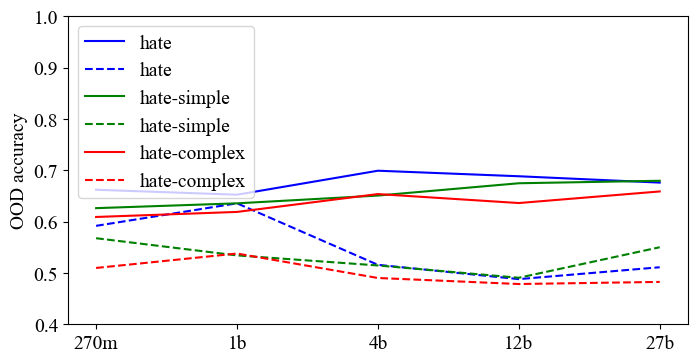

In [ ]:
model_family = "gemma-3"

scales = {0: "0_6B", 1: "1_7B", 2: "4B", 3: "8B", 4: "14B", 5: "32B"} #Qwen3-family
scales = {0: "270m", 1: "1b", 2: "4b", 3: "12b", 4: "27b"} #gemma-3 model-family
#scales = {0: "base", 1: "toxicity"}
if model_family == "gemma-3":
    it = "-it"
else:
    it = ""

group = "b1" #a, b1, b2, c

fig = plt.figure(figsize=(8, 4))

font = {'family' : 'Times New Roman',
        'size'   : 14}

plt.rc('font', **font)

def get_accs(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = full_accs[model][layer][probe_type][to_str(medley)].copy()
    for d in drop:
        del accs[d]
    return accs

def get_avg(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = get_accs(full_accs, model, layer, probe_type, medley, drop=drop)
    return sum(value for value in accs.values() if isinstance(value, float)) / len(accs)

def get_layer(model: str, group: str) -> str:
    return eval(config[model][f'probe_layer_{group}'])


# ccs_medlies = [
#     ["code-review-dataset-smaller"],
#     ["code-review-dataset-smaller"],
# ]
#'Qwen3-{scales[i]}B'
#'gemma-3-{scales[i]}-it'

# plt.plot(
#     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["code-review-dataset-larger"]) for i in range(len(scales))], 'r--', label='code-reviews'
# )
# plt.plot(
#     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["code-review-dataset-larger", "neg-code-review-larger"], ["code-review-dataset-larger", "neg-code-review-larger"]) for i in range(len(scales))], 'r-', label='code+neg_code'
# )
# plt.plot(
#     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["gitter_ethereum-labeled-larger"], ["code-review-dataset-larger", "neg-code-review-larger"]) for i in range(len(scales))], 'b--', label='gitter'
# )
# plt.plot(
#     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"], ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"]) for i in range(len(scales))], 'b-', label='gitter+neg_gitter'
# )
# plt.plot(
#     [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['oracle'] for i in range(len(scales))], 'k-', label='LR on test set (oracle)'
# )
plt.plot(
    [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["hatecheck_balanced"], ["hatecheck_validation_balanced"]) for i in range(len(scales))], 'b-', label='hate'
)
plt.plot(
    [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'MMProbe', ["hatecheck_balanced"], ["hatecheck_validation_balanced"]) for i in range(len(scales))], 'b--', label='hate'
)
plt.plot(
    [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["hatecheck_simple_balanced"], ["hatecheck_validation_balanced"]) for i in range(len(scales))], 'g-', label='hate-simple'
)
plt.plot(
    [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'MMProbe', ["hatecheck_simple_balanced"], ["hatecheck_validation_balanced"]) for i in range(len(scales))], 'g--', label='hate-simple'
)
plt.plot(
    [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'LRProbe', ["hatecheck_complex_balanced"], ["hatecheck_validation_balanced"]) for i in range(len(scales))], 'r-', label='hate-complex'
)
plt.plot(
    [get_avg(accssss, f'{model_family}-{scales[i]}{it}', get_layer(f'{model_family}-{scales[i]}{it}', group=group), 'MMProbe', ["hatecheck_complex_balanced"], ["hatecheck_validation_balanced"]) for i in range(len(scales))], 'r--', label='hate-complex'
)
# plt.plot(
#     [averagesss[f'llama-2-{scales[i]}b']['LRProbe']['likely'] for i in range(len(scales))], '-', color='gray', label='likely'
# )

# set x ticks
plt.xticks(range(len(scales)), [f'{scales[i]}' for i in range(len(scales))])

plt.ylabel('OOD accuracy')

plt.ylim(0.4, 1)
plt.legend()
#plt.savefig('junk/duplicate_generalization.pdf', bbox_inches='tight')

plt.show()




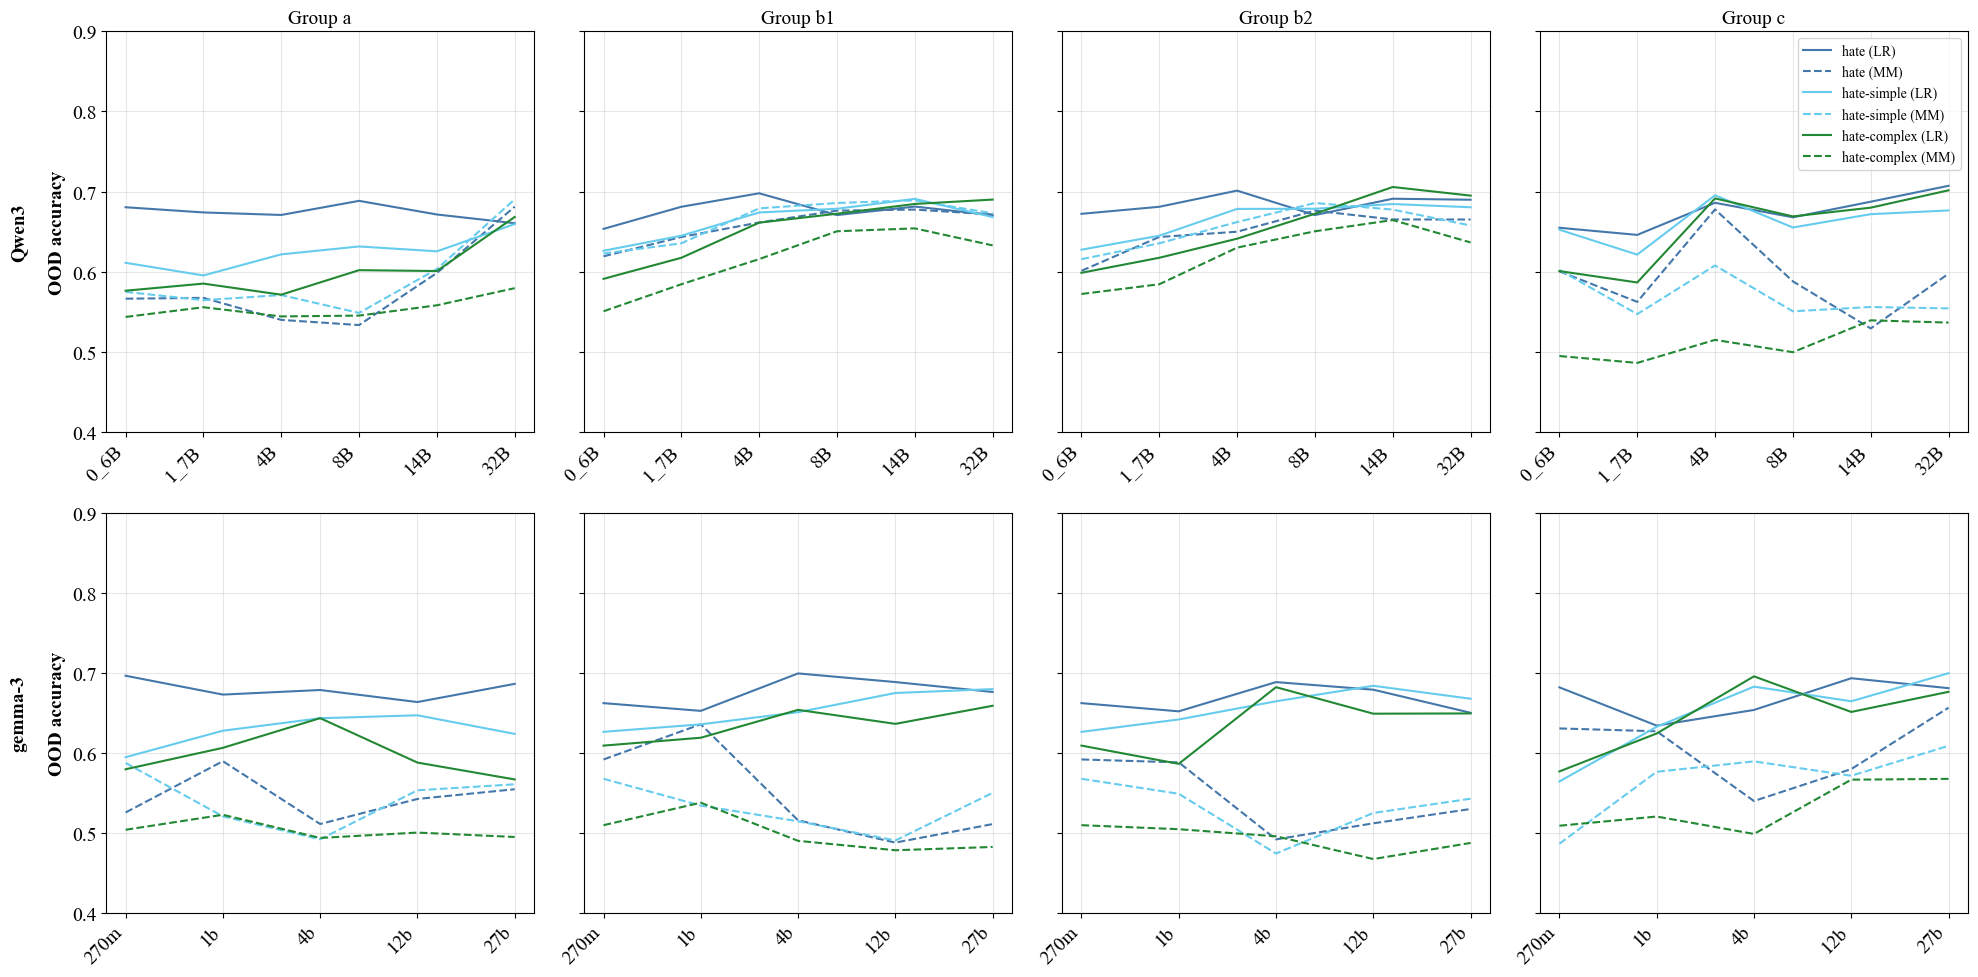

In [73]:
import matplotlib.pyplot as plt

# Define model families and groups
model_families = ["Qwen3", "gemma-3"]
groups = ["a", "b1", "b2", "c"]
#model_families = ["roberta"]
#groups = ["a", "b"]

# Scale definitions for different model families
scales_dict = {
    "Qwen3": {0: "0_6B", 1: "1_7B", 2: "4B", 3: "8B", 4: "14B", 5: "32B"},
    "gemma-3": {0: "270m", 1: "1b", 2: "4b", 3: "12b", 4: "27b"},
    #"roberta": {0: "base", 1: "toxicity"}
}

# Helper functions
def get_accs(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = full_accs[model][layer][probe_type][to_str(medley)].copy()
    for d in drop:
        del accs[d]
    return accs

def get_avg(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = get_accs(full_accs, model, layer, probe_type, medley, drop=drop)
    return sum(value for value in accs.values() if isinstance(value, float)) / len(accs)

def get_layer(model: str, group: str) -> str:
    return eval(config[model][f'probe_layer_{group}'])

def get_it_suffix(model_family):
    return "-it" if model_family == "gemma-3" else ""

# Set up the figure with subplots
fig, axes = plt.subplots(len(model_families), len(groups), 
                         figsize=(20, 10), 
                         sharey=True)

# Configure font
font = {'family': 'Times New Roman', 'size': 14}
plt.rc('font', **font)

# Store line handles and labels for the shared legend
handles, labels = None, None

# Iterate through model families (rows) and groups (columns)
for row_idx, model_family in enumerate(model_families):
    scales = scales_dict[model_family]
    it = get_it_suffix(model_family)
    
    for col_idx, group in enumerate(groups):
        ax = axes[row_idx, col_idx]
        #ax = axes[col_idx]
        # HateCheck
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', ["hatecheck_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], color="#4477AA", linestyle="-", label='hate (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', ["hatecheck_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], color="#4477AA", linestyle="--", label='hate (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', ["hatecheck_simple_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], color="#66CCEE", linestyle="-", label='hate-simple (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', ["hatecheck_simple_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], color="#66CCEE", linestyle="--", label='hate-simple (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', ["hatecheck_complex_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], color="#228833", linestyle="-", label='hate-complex (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', ["hatecheck_complex_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], color="#228833", linestyle="--", label='hate-complex (MM)'
        )

        # Code Dataset
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'LRProbe', ["code-review-dataset-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#CCBB44", linestyle="-", label='code (LR)'
        # )
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'MMProbe', ["code-review-dataset-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#CCBB44", linestyle="--", label='code (MM)'
        # )
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'LRProbe', ["code-review-dataset-larger", "neg-code-review-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#AA8800", linestyle="-", label='code+neg_code (LR)'
        # )
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'MMProbe', ["code-review-dataset-larger", "neg-code-review-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#AA8800", linestyle="--", label='code+neg_code (MM)'
        # )

        # # Gitter dataset
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'LRProbe', ["gitter_ethereum-labeled-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#EE6677", linestyle="-", label='gitter (LR)'
        # )
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'MMProbe', ["gitter_ethereum-labeled-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#EE6677", linestyle="--", label='gitter (MM)'
        # )
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'LRProbe', ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))], color="#AA3377", linestyle="-", label='gitter+neg_gitter (LR)'
        # )
        # ax.plot(
        #     [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
        #             get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
        #             'MMProbe', ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"], ["cumstrudel_train_comments_balanced"]) 
        #      for i in range(len(scales))],  color="#AA3377", linestyle="--", label='gitter+neg_gitter (MM)'
        # )
        # Set x-axis ticks based on the model family's scales
        ax.set_xticks(range(len(scales)))
        ax.set_xticklabels([f'{scales[i]}' for i in range(len(scales))], rotation=45, ha='right')
        
        # Set y-axis limits
        ax.set_ylim(0.4, 0.9)
        
        # Add column titles (groups) at the top
        if row_idx == 0:
            ax.set_title(f'Group {group}', fontsize=14, )
        
        # Add row labels (model families) on the left
        if col_idx == 0:
            ax.set_ylabel(f'{model_family}\n\nOOD accuracy', fontsize=14, fontweight='bold')
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3)
        
        # Collect handles and labels from the first subplot for shared legend
        if handles is None and labels is None:
            handles, labels = ax.get_legend_handles_labels()
        
        # Add legend to the group c plot of the first model family
        if row_idx == 0 and col_idx == len(groups) - 1:
            ax.legend(handles, labels, loc='best', fontsize=10, frameon=True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save or show the figure
plt.savefig('generalization_ood_acc_hatecheck.pdf', bbox_inches='tight')
plt.show()

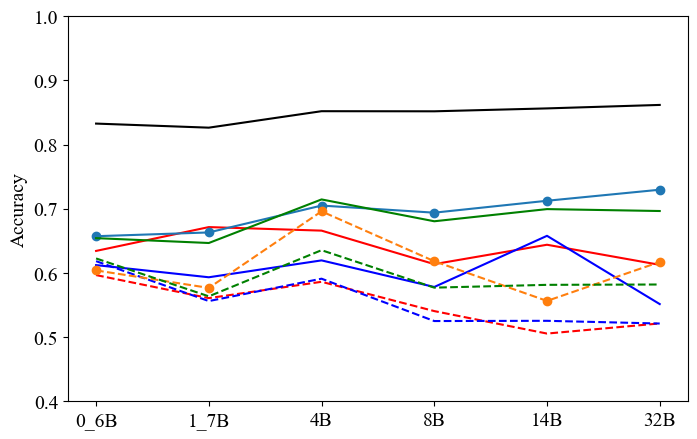

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["hatecheck_balanced"] for i in range(len(scales))], 'o-'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["hatecheck_balanced"] for i in range(len(scales))], 'o--'
)

plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["hatecheck_simple_balanced"] for i in range(len(scales))], 'g-'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["hatecheck_simple_balanced"] for i in range(len(scales))], 'g--'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["code-review-dataset-larger"] for i in range(len(scales))], 'r-',
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["code-review-dataset-larger"]for i in range(len(scales))], 'r--'
)
# plt.plot(
#     [averagesss[f'llama-2-{scales[i]}b']['CCSProbe']['cities+neg_cities'] for i in range(3)], 'r:'
# )
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["code-review-dataset-larger+neg-code-review-larger"] for i in range(len(scales))], 'b-'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["code-review-dataset-larger+neg-code-review-larger"] for i in range(len(scales))], 'b--'
)
# plt.plot(
#     [averagesss[f'llama-2-{scales[i]}b']['CCSProbe']['larger_than+smaller_than'] for i in range(3)], 'b:'
# )

plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['oracle'] for i in range(len(scales))], 'k-'
)
# plt.plot(
#     [averagesss[f'llama-2-{scales[i]}b']['LRProbe']['likely'] for i in range(3)], '-', color='gray'
# )
# plt.plot(
#     [averagesss[f'llama-2-{scales[i]}b']['MMProbe']['likely'] for i in range(3)], '--', color='gray'

# )
plt.ylim(0.4, 1)

plt.xticks(range(len(scales)), [f'{scales[i]}' for i in range(len(scales))])

plt.ylabel('Accuracy')

plt.ylim(0.4, 1)


plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Define model families and groups
model_families = ["Qwen3", "gemma-3"]
groups = ["a", "b1", "b2", "c"]

# Scale definitions for different model families
scales_dict = {
    "Qwen3": {0: "0_6B", 1: "1_7B", 2: "4B", 3: "8B", 4: "14B", 5: "32B"},
    "gemma-3": {0: "270m", 1: "1b", 2: "4b", 3: "12b", 4: "27b"}
}

# Helper functions
def get_accs(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = full_accs[model][layer][probe_type][to_str(medley)].copy()
    for d in drop:
        del accs[d]
    return accs

def get_avg(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = get_accs(full_accs, model, layer, probe_type, medley, drop=drop)
    return sum(value for value in accs.values() if isinstance(value, float)) / len(accs)

def get_layer(model: str, group: str) -> str:
    return eval(config[model][f'probe_layer_{group}'])

def get_it_suffix(model_family):
    return "-it" if model_family == "gemma-3" else ""

# Set up the figure with subplots
fig, axes = plt.subplots(len(model_families), len(groups), 
                         figsize=(20, 10), 
                         sharey=True)

# Configure font
font = {'family': 'Times New Roman', 'size': 14}
plt.rc('font', **font)

# Store line handles and labels for the shared legend
handles, labels = None, None

# Iterate through model families (rows) and groups (columns)
for row_idx, model_family in enumerate(model_families):
    scales = scales_dict[model_family]
    it = get_it_suffix(model_family)
    
    for col_idx, group in enumerate(groups):
        ax = axes[row_idx, col_idx]
        
        # Plot all the lines
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', ["hatecheck_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], 
            'b-', label='hate (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', ["hatecheck_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], 
            'b--', label='hate (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', ["hatecheck_simple_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], 
            'g-', label='hate-simple (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', ["hatecheck_simple_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], 
            'g--', label='hate-simple (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', ["hatecheck_complex_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], 
            'r-', label='hate-complex (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', ["hatecheck_complex_balanced"], ["hatecheck_validation_balanced"]) 
             for i in range(len(scales))], 
            'r--', label='hate-complex (MM)'
        )
        
        # Set x-axis ticks based on the model family's scales
        ax.set_xticks(range(len(scales)))
        ax.set_xticklabels([f'{scales[i]}' for i in range(len(scales))], rotation=45, ha='right')
        
        # Set y-axis limits
        ax.set_ylim(0.4, 1)
        
        # Add column titles (groups) at the top
        if row_idx == 0:
            ax.set_title(f'Group {group}', fontsize=16, fontweight='bold')
        
        # Add row labels (model families) on the left
        if col_idx == 0:
            ax.set_ylabel(f'{model_family}\n\nOOD accuracy', fontsize=14, fontweight='bold')
        elif col_idx == len(groups) // 2:
            # Only add "OOD accuracy" for middle columns
            ax.set_ylabel('OOD accuracy', fontsize=14)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3)
        
        # Collect handles and labels from the first subplot for shared legend
        if handles is None and labels is None:
            handles, labels = ax.get_legend_handles_labels()
        
        # Add legend to the group c plot of the first model family
        if row_idx == 0 and col_idx == len(groups) - 1:
            ax.legend(handles, labels, loc='best', fontsize=10, frameon=True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save or show the figure
# plt.savefig('multi_subplot_visualization.pdf', bbox_inches='tight')
plt.show()

7
7


KeyError: 'few_shot'

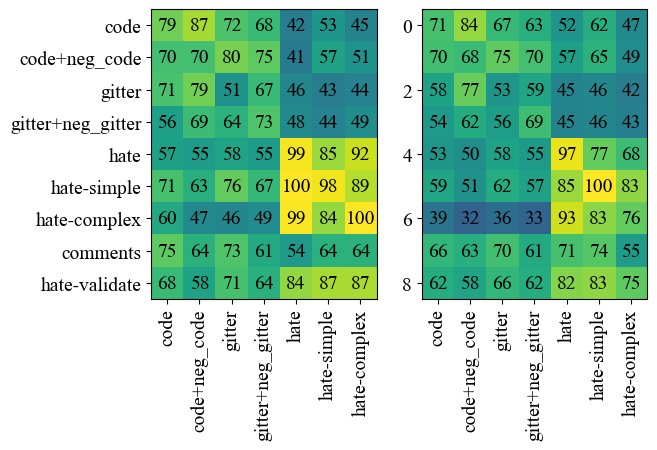

In [ ]:
fig, axes = plt.subplots(1, 2)

model = 'Qwen3-32B'
group = "a"

labels_x = ["code", "code+neg_code", "gitter", "gitter+neg_gitter", "hate", "hate-simple", "hate-complex"]
labels_y = ["code", "code+neg_code", "gitter", "gitter+neg_gitter", "hate", "hate-simple", "hate-complex", "comments", "hate-validate"] #, "issues"

def make_axis(ax, model, layer, probe_type, medlies, labels_x = [], labels_y = [], do_yticks=False):
    grid = [ [None for _ in medlies] for _ in val_datasets]
    for i, dataset in enumerate(val_datasets):
        for j, medley in enumerate(medlies):
            grid[i][j] = get_accs(accssss, model, layer, probe_type, medley)[dataset]
    ax.imshow(grid, vmin=0, vmax=1)

    for i in range(len(grid)):
        for j in range(len(grid[0])):
            ax.text(j, i, f'{round(grid[i][j] * 100):2d}', ha='center', va='center')
    print(len(medlies))
    ax.set_xticks(range(len(labels_x)))
    ax.set_xticklabels(labels_x, rotation=90)
    if do_yticks:
        ax.set_yticks(range(len(labels_y)))
        ax.set_yticklabels(labels_y)

make_axis(axes[0], model, get_layer(model, group=group), 'LRProbe', [["hatecheck_balanced"],
                                                                     ["hatecheck_simple_balanced"],
                                                                     ["hatecheck_complex_balanced"],
                                                                     ['code-review-dataset-larger'], 
                                                                     ["code-review-dataset-larger", "neg-code-review-larger"], 
                                                                     ["gitter_ethereum-labeled-larger"], 
                                                                     ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"],
                                                                    #  ["cumstrudel_train_issues_balanced"],
                                                                    #["cumstrudel_train_comments_balanced"]
                                                                    ], labels_x, labels_y, do_yticks=True)

make_axis(axes[1], model, get_layer(model, group=group), 'MMProbe', [["hatecheck_balanced"],
                                                                     ["hatecheck_simple_balanced"],
                                                                     ["hatecheck_complex_balanced"],
                                                                     ['code-review-dataset-larger'], 
                                                                     ["code-review-dataset-larger", "neg-code-review-larger"], 
                                                                     ["gitter_ethereum-labeled-larger"], 
                                                                     ["gitter_ethereum-labeled-larger", "neg-gitter-ethereum-labeled-larger"],
                                                                     #["cumstrudel_train_issues_balanced"],
                                                                     #["cumstrudel_train_comments_balanced"]
                                                                     ], labels_x, labels_y, do_yticks=False)#[['cities'], ['cities', 'neg_cities'], ['larger_than'], ['larger_than', 'smaller_than']])

#make_axis(axes[2], model, 'CCSProbe', [['cities', 'neg_cities'], ['larger_than', 'smaller_than']])

grid = [ [None for _ in range(4)] for _ in val_datasets]
for i, dataset in enumerate(val_datasets):
    #grid[i][0] = get_accs(accssss, model, 'LRProbe', ['likely'])[dataset]
    #grid[i][1] = get_accs(accssss, model, 'MMProbe', ['likely'])[dataset]
    grid[i][0] = accssss[model][get_layer(model, group=group)]['few_shot'][dataset]
    grid[i][1] = accssss[model][get_layer(model, group=group)]['oracle'][dataset]
axes[2].imshow(grid, vmin=0, vmax=1)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels([])
axes[2].set_yticks([])
axes[2].set_yticklabels([])

for i in range(len(grid)):
    for j in range(len(grid[0])):
        axes[2].text(j, i, f'{round(grid[i][j] * 100):2d}', ha='center', va='center')

axes[0].set_yticks(range(len(val_datasets)))
axes[0].set_yticklabels([])

# add colorbar
plt.colorbar(axes[0].images[0])

#fig.savefig('junk/llama-2-7b_generalization.pdf')
fig.show()
        

In [ ]:
print(accssss["gemma-3-1b-it"][8])

## Non-Knowledge Generalization

In [136]:
# hyperparameters
model = 'Qwen3-32B'
split = 0.8
device = "cpu"

config = configparser.ConfigParser()
config.read('config_nk.ini')
layer_a = eval(config[model]['probe_layer_a'])
layer_b = eval(config[model]['probe_layer_b'])
#layer_b = eval(config[model]['probe_layer_b'])
layer_c = eval(config[model]['probe_layer_c'])
layer_d = eval(config[model]['probe_layer_d'])
noperiod = eval(config[model]['noperiod'])

In [126]:
dataset = "knowledge_non_knowledge_v3_rephrased_gpt_120b"

df = pd.read_csv(f"datasets/{dataset}.csv")
repos = df["Repo"].unique()
train_medlies = []
val_datasets = []
train_dict = {}
val_dict = {}

for repo in repos:
    test_mask = df['Repo'] == repo
    train_mask = ~test_mask

    train_df = df[train_mask]
    test_df = df[test_mask]

    # balance training
    train_label_0 = train_df[train_df['original_binary_NK_label'] == 0]
    train_label_1 = train_df[train_df['original_binary_NK_label'] == 1]
    min_train_samples = min(len(train_label_0), len(train_label_1))
    train_balanced = pd.concat([
        train_label_0.sample(n=min_train_samples, random_state=42),
        train_label_1.sample(n=min_train_samples, random_state=42)
    ])

    # balance test
    test_label_0 = test_df[test_df['original_binary_NK_label'] == 0]
    test_label_1 = test_df[test_df['original_binary_NK_label'] == 1]
    min_test_samples = min(len(test_label_0), len(test_label_1))
    test_balanced = pd.concat([
        test_label_0.sample(n=min_test_samples, random_state=42),
        test_label_1.sample(n=min_test_samples, random_state=42)
    ])

    train_indices = train_balanced.index.tolist()
    test_indices = test_balanced.index.tolist()

    train_medlies.append(f"k_nk_ex_{repo}")
    val_datasets.append(f"k_nk_val_{repo}")

    train_dict[f"k_nk_ex_{repo}"] = train_indices
    val_dict[f"k_nk_val_{repo}"] = test_indices

def to_str(l):
    return '+'.join(l)

In [4]:
for val, medley in zip(val_datasets, train_medlies):
    print(val, medley)

k_nk_val_pytorch_pytorch k_nk_ex_pytorch_pytorch
k_nk_val_tensorflow_tensorflow k_nk_ex_tensorflow_tensorflow
k_nk_val_numpy_numpy k_nk_ex_numpy_numpy
k_nk_val_microsoft_vscode k_nk_ex_microsoft_vscode


In [137]:
ProbeClasses = [
    LRProbe, 
    MMProbe, 
    ]

layers = [layer_a, layer_b, layer_c, layer_d]
#layers = [layer_a, layer_b]
accs = {layer: {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses} for layer in layers}

with open('all_non_knowledge_results/experimental_outputs/non_knowledge_generalization_results.json', 'r') as f:
    outs = json.load(f)

for layer in layers:
    print(layer)
    for ProbeClass in ProbeClasses:
        for val, medley in zip(val_datasets, train_medlies):

            # set up data
            dm = DataManager()
            dm.add_dataset(dataset, model, layer, split=True, train_indices=train_dict[medley], test_indices=val_dict[val], label="original_binary_NK_label", noperiod=noperiod, center=True, device=device)

            # train probe
            train_acts, train_labels = dm.get('train')
            probe = ProbeClass.from_data(train_acts, train_labels) #
            direction = probe.direction

            acts, labels = dm.data['val'][dataset]
            accs[layer][str(ProbeClass)][to_str(medley)][val] = (
                probe.pred(acts, iid=True) == labels
            ).float().mean().item()
        # else:
        #     acts, labels = dm.data[val_dataset]
        #     #print(acts.size())
        #     accs[layer][str(ProbeClass)][to_str(medley)][val_dataset] = (
        #         probe.pred(acts, iid=False) == labels
        #     ).float().mean().item()
        out = accs[layer][str(ProbeClass)]
        out['model'] = model
        out['probe'] = ProbeClass.__str__()
        out['layer'] = layer
        out['oracle'] = False
        out['noperiod'] = noperiod
        outs.append(out)
    

lr_mm_accs = accs.copy()


# for ProbeClass in ProbeClasses:
#     out = accs[str(ProbeClass)]
#     out['model'] = model
#     out['probe'] = ProbeClass.__str__()
#     out['layer'] = layer
#     out['oracle'] = False
#     out['noperiod'] = noperiod
#     outs.append(out)

with open('all_non_knowledge_results/experimental_outputs/non_knowledge_generalization_results.json', 'w') as f:
    json.dump(outs, f, indent=2)

34
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-32B/knowledge_non_knowledge_v3_rephrased_gpt_120b
250 : 140
torch.Size([504, 5120])
torch.Size([140, 5120])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-32B/knowledge_non_knowledge_v3_rephrased_gpt_120b
260 : 100
torch.Size([504, 5120])
torch.Size([100, 5120])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-32B/knowledge_non_knowledge_v3_rephrased_gpt_120b
320 : 70
torch.Size([504, 5120])
torch.Size([70, 5120])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-32B/knowledge_non_knowledge_v3_rephrased_gpt_120b
340 : 50
torch.Size([504, 5120])
torch.Size([50, 5120])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-toxicity/data/acts/Qwen3-32B/knowledge_non_knowledge_v3_rephrased_gpt_120b
250 : 140
torch.Size([504, 5120])
torch.Size([140, 5120])
Directory: /Volumes/Samsung SSD 990 PRO 4TB/geometry-of-

In [138]:
models = ["Qwen3-0_6B", "Qwen3-1_7B", "Qwen3-4B", "Qwen3-8B", "Qwen3-14B", "Qwen3-32B", "gemma-3-270m-it", "gemma-3-1b-it", "gemma-3-4b-it", "gemma-3-12b-it", "gemma-3-27b-it"]
#models = ["roberta-base","roberta-toxicity"]
#models = ["gemma-3-270m-it", "gemma-3-1b-it", "gemma-3-4b-it", "gemma-3-12b-it", "gemma-3-27b-it"]
ProbeClasses = [LRProbe, MMProbe]
#models=["gemma-3-27b-it"]

# load data
with open('all_non_knowledge_results/experimental_outputs/non_knowledge_generalization_results.json', 'r') as f:
    outs = json.load(f)

accssss = {} 
averagesss = {}
for model in models:
    layer_a = eval(config[model]['probe_layer_a'])
    layer_b = eval(config[model]['probe_layer_b'])
    #layer_b = eval(config[model]['probe_layer_b'])
    layer_c = eval(config[model]['probe_layer_c'])
    layer_d = eval(config[model]['probe_layer_d'])
    layers = [layer_a, layer_b, layer_c, layer_d]
    #layers = [layer_a, layer_b]
    accsss = {layer: {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses} for layer in layers}
    averagess = {layer: {str(probe_class) : {to_str(train_medley) : {} for train_medley in train_medlies} for probe_class in ProbeClasses} for layer in layers}
    # get LR and MM results
    for layer in layers:
        for ProbeClass in [LRProbe, MMProbe]:
            accss = {}
            averages = {}
            for train_medley in train_medlies:
                for out in outs:
                    if out['model'] == model and out['probe'] == ProbeClass.__str__() and out['oracle'] == False and out["layer"] == layer:
                        accs = out[to_str(train_medley)] #to_str(train_medley)
                        break
                #value = list(accs.keys())[0]
                accss[to_str(train_medley)] = accs
                average = sum(value for value in accs.values() if isinstance(value, float)) / len(accs)
                averages[to_str(train_medley)] = average
            accsss[layer][ProbeClass.__str__()] = accss
            averagess[layer][ProbeClass.__str__()] = averages
    
        # get oracle results
        # for ProbeClass in ['oracle']:
        #     accss = {}
        #     for out in outs:
        #         if out['model'] == model and out['oracle'] == True and out['probe'] == 'LRProbe' and out["layer"] == layer:
        #             accs = out
        #     # filter for numbers
        #     filtered_accs = {}
        #     for val_dataset in val_datasets:
        #         filtered_accs[val_dataset] = accs[val_dataset]
        #     accsss[layer]['oracle'] = filtered_accs
        #     averagess[layer][ProbeClass.__str__()] = sum(filtered_accs.values()) / len(filtered_accs)

    accssss[model] = accsss
    averagesss[model] = averagess


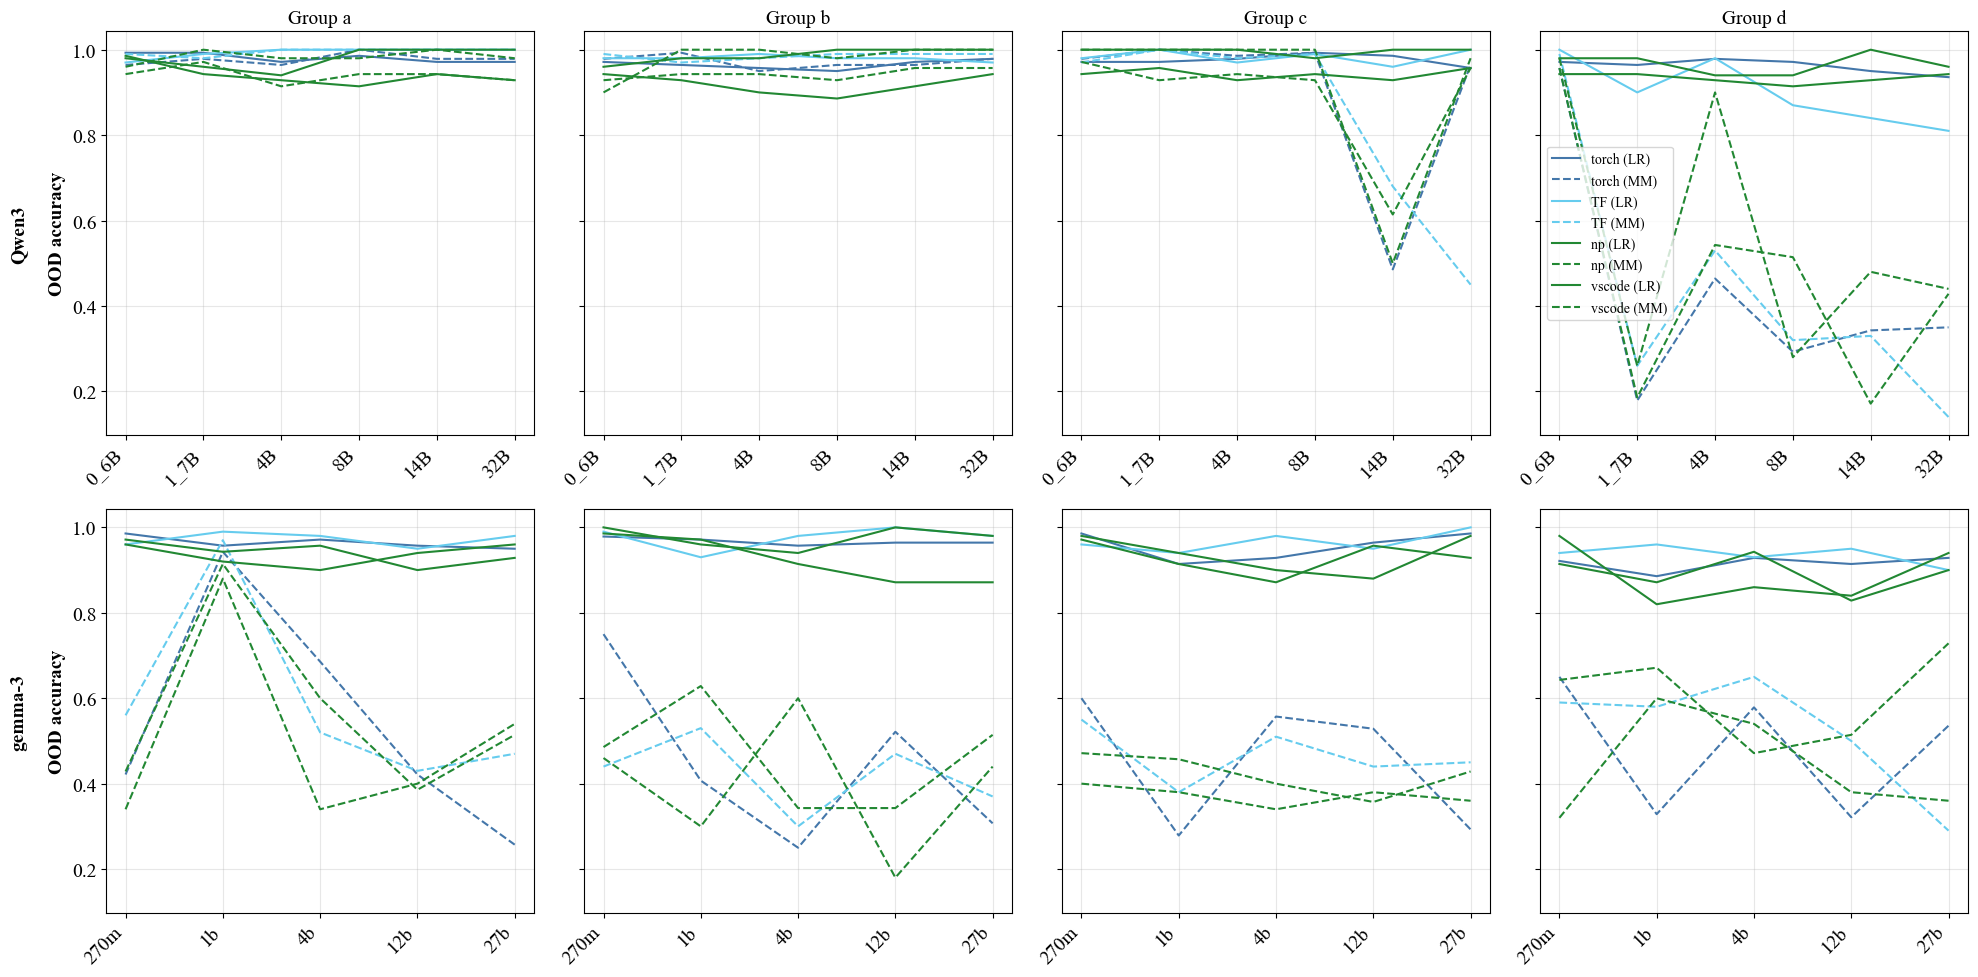

In [139]:
import matplotlib.pyplot as plt

# Define model families and groups
model_families = ["Qwen3", "gemma-3"]
groups = ["a", "b", "c", "d"]
#model_families = ["roberta"]
#groups = ["a", "b"]

# Scale definitions for different model families
scales_dict = {
    "Qwen3": {0: "0_6B", 1: "1_7B", 2: "4B", 3: "8B", 4: "14B", 5: "32B"},
    "gemma-3": {0: "270m", 1: "1b", 2: "4b", 3: "12b", 4: "27b"},
    #"roberta": {0: "base", 1: "toxicity"}
}

# Helper functions
def get_accs(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = full_accs[model][layer][probe_type][to_str(medley)].copy()
    for d in drop:
        del accs[d]
    return accs

def get_avg(full_accs, model, layer, probe_type, medley, drop=[]):
    accs = get_accs(full_accs, model, layer, probe_type, medley, drop=drop)
    return sum(value for value in accs.values() if isinstance(value, float)) / len(accs)

def get_layer(model: str, group: str) -> str:
    return eval(config[model][f'probe_layer_{group}'])

def get_it_suffix(model_family):
    return "-it" if model_family == "gemma-3" else ""

# Set up the figure with subplots
fig, axes = plt.subplots(len(model_families), len(groups), 
                         figsize=(20, 10), 
                         sharey=True)

# Configure font
font = {'family': 'Times New Roman', 'size': 14}
plt.rc('font', **font)

# Store line handles and labels for the shared legend
handles, labels = None, None

# Iterate through model families (rows) and groups (columns)
for row_idx, model_family in enumerate(model_families):
    scales = scales_dict[model_family]
    it = get_it_suffix(model_family)
    
    for col_idx, group in enumerate(groups):
        ax = axes[row_idx, col_idx]
        #ax = axes[col_idx]
        # HateCheck
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', "k_nk_ex_pytorch_pytorch") 
             for i in range(len(scales))], color="#4477AA", linestyle="-", label='torch (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', "k_nk_ex_pytorch_pytorch") 
             for i in range(len(scales))], color="#4477AA", linestyle="--", label='torch (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', "k_nk_ex_tensorflow_tensorflow") 
             for i in range(len(scales))], color="#66CCEE", linestyle="-", label='TF (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', "k_nk_ex_tensorflow_tensorflow") 
             for i in range(len(scales))], color="#66CCEE", linestyle="--", label='TF (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', "k_nk_ex_numpy_numpy") 
             for i in range(len(scales))], color="#228833", linestyle="-", label='np (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', "k_nk_ex_numpy_numpy") 
             for i in range(len(scales))], color="#228833", linestyle="--", label='np (MM)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'LRProbe', "k_nk_ex_microsoft_vscode") 
             for i in range(len(scales))], color="#228833", linestyle="-", label='vscode (LR)'
        )
        ax.plot(
            [get_avg(accssss, f'{model_family}-{scales[i]}{it}', 
                    get_layer(f'{model_family}-{scales[i]}{it}', group=group), 
                    'MMProbe', "k_nk_ex_microsoft_vscode") 
             for i in range(len(scales))], color="#228833", linestyle="--", label='vscode (MM)'
        )

        ax.set_xticks(range(len(scales)))
        ax.set_xticklabels([f'{scales[i]}' for i in range(len(scales))], rotation=45, ha='right')
        
        # Set y-axis limits
        #ax.set_ylim(0.4, 0.9)
        
        # Add column titles (groups) at the top
        if row_idx == 0:
            ax.set_title(f'Group {group}', fontsize=14, )
        
        # Add row labels (model families) on the left
        if col_idx == 0:
            ax.set_ylabel(f'{model_family}\n\nOOD accuracy', fontsize=14, fontweight='bold')
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3)
        
        # Collect handles and labels from the first subplot for shared legend
        if handles is None and labels is None:
            handles, labels = ax.get_legend_handles_labels()
        
        # Add legend to the group c plot of the first model family
        if row_idx == 0 and col_idx == len(groups) - 1:
            ax.legend(handles, labels, loc='best', fontsize=10, frameon=True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save or show the figure
#plt.savefig('generalization_ood_acc_hatecheck.pdf', bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["k_nk_v_pytorch_pytorch"] for i in range(len(scales))], 'o-'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["k_nk_ex_pytorch_pytorch"] for i in range(len(scales))], 'o--'
)

plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["k_nk_ex_tensorflow_tensorflow"] for i in range(len(scales))], 'g-'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["k_nk_ex_tensorflow_tensorflow"] for i in range(len(scales))], 'g--'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["k_nk_ex_numpy_numpy"] for i in range(len(scales))], 'r-',
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["k_nk_ex_numpy_numpy"]for i in range(len(scales))], 'r--'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['LRProbe']["k_nk_ex_microsoft_vscode"] for i in range(len(scales))], 'b-'
)
plt.plot(
    [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['MMProbe']["k_nk_ex_microsoft_vscode"] for i in range(len(scales))], 'b--'
)

# plt.plot(
#     [averagesss[f'{model_family}-{scales[i]}{it}'][get_layer(f'{model_family}-{scales[i]}{it}', group=group)]['oracle'] for i in range(len(scales))], 'k-'
# )
plt.ylim(0.4, 1)

plt.xticks(range(len(scales)), [f'{scales[i]}' for i in range(len(scales))])

plt.ylabel('Accuracy')

plt.ylim(0.4, 1)


plt.show()

KeyError: 'k_nk_val_pytorch_pytorch'

<Figure size 800x500 with 0 Axes>

0.9571428298950195
1.0
0.9571428298950195
1.0
4
0.9642857313156128
0.44999998807907104
0.9571428298950195
0.9800000190734863
4


KeyError: 'few_shot'

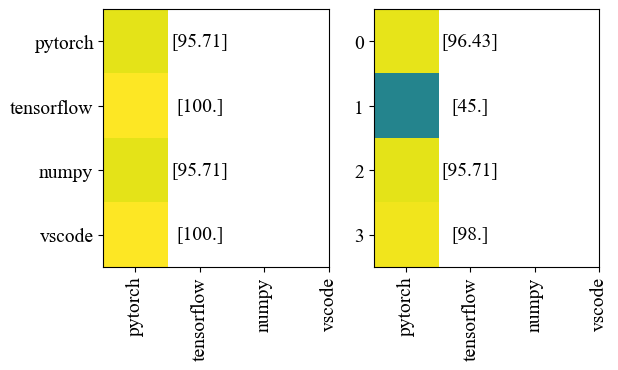

In [147]:
fig, axes = plt.subplots(1, 2)

model = 'Qwen3-32B'
group = "c"

labels_x = ["pytorch", "tensorflow", "numpy", "vscode"]
labels_y = ["pytorch", "tensorflow", "numpy", "vscode"] #, "issues"

def make_axis(ax, model, layer, probe_type, medlies, labels_x = [], labels_y = [], do_yticks=False):
    grid = [ None for _ in val_datasets]
    for i, (medley, dataset) in enumerate(zip(medlies, val_datasets)):
        grid[i] = get_accs(accssss, model, layer, probe_type, medley)[dataset]
        #grid[i] = acc.values() # assuming only one value is stored in this dict
        print(grid[i])
    grid = np.array(grid).reshape(4, 1)
    ax.imshow(grid, vmin=0, vmax=1)

    for i in range(len(grid)):
        ax.text(1, i, f'{np.round(grid[i] * 100, 2)}', ha='center', va='center')
    print(len(medlies))
    ax.set_xticks(range(len(labels_x)))
    ax.set_xticklabels(labels_x, rotation=90)
    if do_yticks:
        ax.set_yticks(range(len(labels_y)))
        ax.set_yticklabels(labels_y)

# k_nk_val_pytorch_pytorch k_nk_ex_pytorch_pytorch
# k_nk_val_tensorflow_tensorflow k_nk_ex_tensorflow_tensorflow
# k_nk_val_numpy_numpy k_nk_ex_numpy_numpy
# k_nk_val_microsoft_vscode k_nk_ex_microsoft_vscode

make_axis(axes[0], model, get_layer(model, group=group), 'LRProbe', ["k_nk_ex_pytorch_pytorch",
                                                                     "k_nk_ex_tensorflow_tensorflow",
                                                                     "k_nk_ex_numpy_numpy",
                                                                     'k_nk_ex_microsoft_vscode', 
                                                                    #["cumstrudel_train_issues_balanced"],
                                                                    #["cumstrudel_train_comments_balanced"]
                                                                    ], labels_x, labels_y, do_yticks=True)

make_axis(axes[1], model, get_layer(model, group=group), 'MMProbe', ["k_nk_ex_pytorch_pytorch",
                                                                     "k_nk_ex_tensorflow_tensorflow",
                                                                     "k_nk_ex_numpy_numpy",
                                                                     'k_nk_ex_microsoft_vscode', 
                                                                     #["cumstrudel_train_issues_balanced"],
                                                                     #["cumstrudel_train_comments_balanced"]
                                                                     ], labels_x, labels_y, do_yticks=False)#[['cities'], ['cities', 'neg_cities'], ['larger_than'], ['larger_than', 'smaller_than']])

#make_axis(axes[2], model, 'CCSProbe', [['cities', 'neg_cities'], ['larger_than', 'smaller_than']])

grid = [ [None for _ in range(4)] for _ in val_datasets]
for i, dataset in enumerate(val_datasets):
    #grid[i][0] = get_accs(accssss, model, 'LRProbe', ['likely'])[dataset]
    #grid[i][1] = get_accs(accssss, model, 'MMProbe', ['likely'])[dataset]
    grid[i][0] = accssss[model][get_layer(model, group=group)]['few_shot'][dataset]
    grid[i][1] = accssss[model][get_layer(model, group=group)]['oracle'][dataset]
axes[2].imshow(grid, vmin=0, vmax=1)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels([])
axes[2].set_yticks([])
axes[2].set_yticklabels([])

for i in range(len(grid)):
    for j in range(len(grid[0])):
        axes[2].text(j, i, f'{round(grid[i][j] * 100):2d}', ha='center', va='center')

axes[0].set_yticks(range(len(val_datasets)))
axes[0].set_yticklabels([])

# add colorbar
plt.colorbar(axes[0].images[0])

#fig.savefig('junk/llama-2-7b_generalization.pdf')
fig.show()
        